# 🎯 考试风险矩阵分析

目标：分析答题稳定性，找出考试时最容易翻车的题目

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path('.').resolve()
db_path = ROOT / 'exam_db.csv'

## 1. 加载考试数据库

In [2]:
df = pd.read_csv(db_path)
df['风险分'] = df['累计错误次数'] * 2 + df['连续错误次数'] * 3 - (df['最近一次结果'] == '正确').astype(int)
df = df.sort_values('风险分', ascending=False)
df

,题目ID,总练习次数,最近一次结果,累计错误次数,连续错误次数,掌握状态,核心考点,最大陷阱,关键代码骨架,风险分
2,1.1.5,2,错误,3,2,高危,NaN,NaN,NaN,12
0,1.1.2,2,错误,2,2,高危,NaN,NaN,NaN,10
3,2.1.1,1,错误,2,1,高危,NaN,NaN,NaN,7
1,1.1.4,1,错误,1,1,高危,NaN,NaN,NaN,5


## 2. 单题稳定性折线图

横轴：练习次数，纵轴：结果（正确=1，错误=0）

如果曲线波动大（1,0,1,0），定性为"运气题"，考试时极易翻车

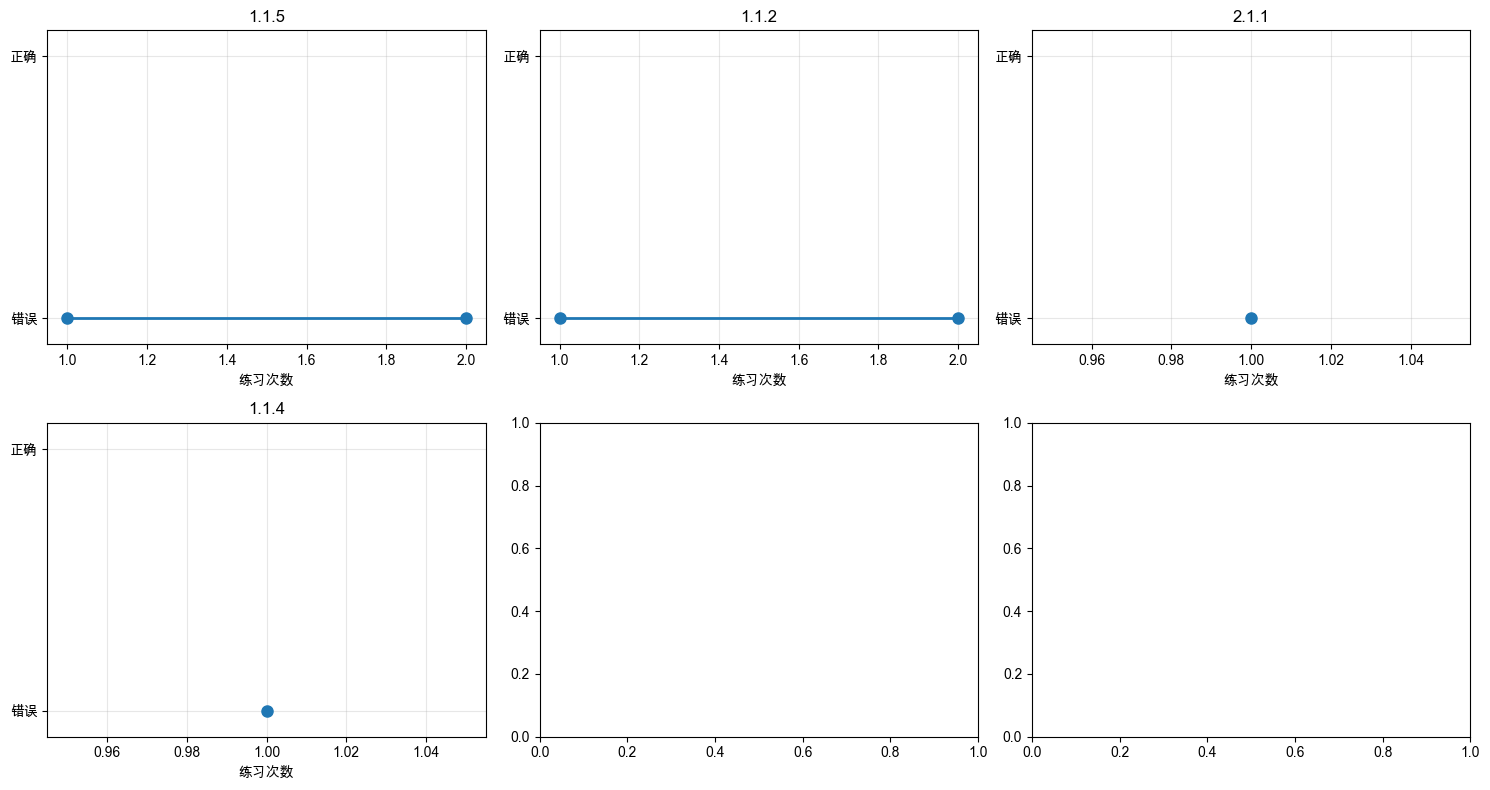

In [3]:
from pathlib import Path

def parse_review_history(topic_id: str):
    """解析某道题的所有 review 文件，返回正确/错误序列"""
    reviews = sorted(ROOT.rglob(f'{topic_id}*review.md'))
    results = []
    for r in reviews:
        content = r.read_text(encoding='utf-8')
        has_error = '错误1' in content or '❌' in content
        results.append(0 if has_error else 1)
    return results

# 绘制所有题目的稳定性曲线
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, topic_id in enumerate(df['题目ID']):
    if idx >= len(axes):
        break
    results = parse_review_history(topic_id)
    if len(results) > 0:
        ax = axes[idx]
        ax.plot(range(1, len(results)+1), results, 'o-', linewidth=2, markersize=8)
        ax.set_ylim(-0.1, 1.1)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['错误', '正确'])
        ax.set_title(f'{topic_id}')
        ax.set_xlabel('练习次数')
        ax.grid(True, alpha=0.3)
        
        # 标记波动大的题目
        if len(results) > 1:
            changes = sum(1 for i in range(1, len(results)) if results[i] != results[i-1])
            if changes >= 2:
                ax.set_facecolor('#fff3cd')  # 黄色背景表示不稳定

plt.tight_layout()
plt.show()

## 3. 首次成功率 vs 最终掌握率

- 首次做对率低但最终做对率高 → "练会了"，不是风险
- 首次做对率高但最终做对率低 → "衰退题"，考试前必须看

In [4]:
# 分析首次和最终成功率
analysis_data = []

for topic_id in df['题目ID']:
    results = parse_review_history(topic_id)
    if len(results) > 0:
        first_success = results[0]
        last_success = results[-1]
        overall_rate = sum(results) / len(results)
        
        analysis_data.append({
            '题目ID': topic_id,
            '首次成功': '✅' if first_success else '❌',
            '最终成功': '✅' if last_success else '❌',
            '总成功率': f'{overall_rate:.0%}',
            '练习次数': len(results),
            '类型': '练会了' if not first_success and last_success else (
                '衰退题' if first_success and not last_success else (
                    '一直对' if first_success and last_success else '一直错'
                )
            )
        })

analysis_df = pd.DataFrame(analysis_data)
analysis_df

,题目ID,首次成功,最终成功,总成功率,练习次数,类型
0,1.1.5,❌,❌,0%,2,一直错
1,1.1.2,❌,❌,0%,2,一直错
2,2.1.1,❌,❌,0%,1,一直错
3,1.1.4,❌,❌,0%,1,一直错


## 4. 考试前24小时急救清单

筛选条件：最近3次平均分 < 60% 或 连续错误 >= 2

输出格式：只输出"题目ID + 陷阱"，不带任何推导过程

In [5]:
# 筛选高危题目
rescue_df = df[(df['连续错误次数'] >= 2) | (df['风险分'] >= 5)].copy()

print("🆘 考试前24小时急救清单\n")
print("=" * 60)

if rescue_df.empty:
    print("✅ 无高危题目，可以直接上考场！")
else:
    for idx, row in rescue_df.iterrows():
        print(f"\n⚠️ {row['题目ID']}")
        print(f"   核心考点：{row.get('核心考点', '未知')}")
        print(f"   最大陷阱：{row.get('最大陷阱', '未知')}")
        print(f"   关键代码：{row.get('关键代码骨架', '未知')}")
        print(f"   风险分：{row['风险分']}")
        print("-" * 60)

print(f"\n共 {len(rescue_df)} 道高危题目需要重点复习")

🆘 考试前24小时急救清单


⚠️ 1.1.5
   核心考点：nan
   最大陷阱：nan
   关键代码：nan
   风险分：12
------------------------------------------------------------

⚠️ 1.1.2
   核心考点：nan
   最大陷阱：nan
   关键代码：nan
   风险分：10
------------------------------------------------------------

⚠️ 2.1.1
   核心考点：nan
   最大陷阱：nan
   关键代码：nan
   风险分：7
------------------------------------------------------------

⚠️ 1.1.4
   核心考点：nan
   最大陷阱：nan
   关键代码：nan
   风险分：5
------------------------------------------------------------

共 4 道高危题目需要重点复习


## 5. 错误趋势分析

整体来看，我的错误是在减少还是在增加？

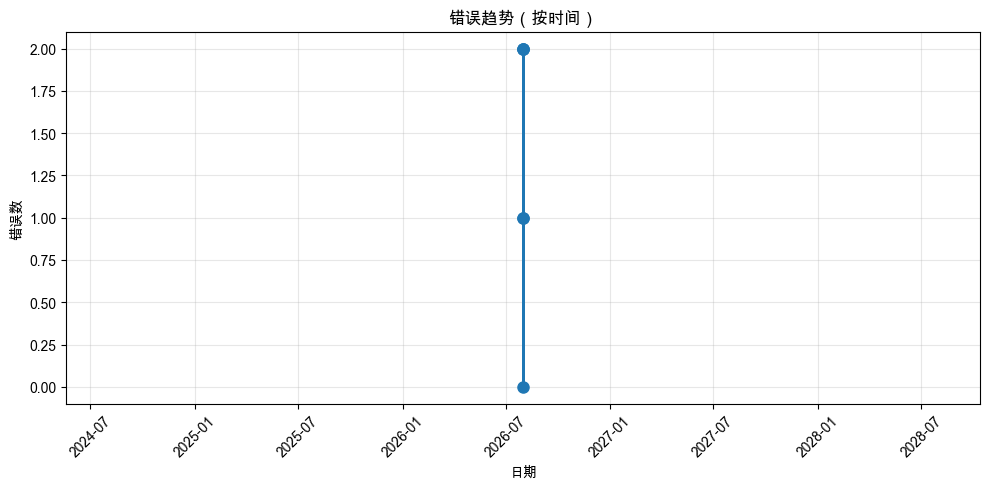

In [6]:
# 按时间顺序分析所有 review 文件
all_reviews = sorted(ROOT.rglob('*_review.md'))

timeline = []
for r in all_reviews:
    content = r.read_text(encoding='utf-8')
    
    # 提取日期
    date_match = re.search(r'Review - (\d{8})', content)
    if date_match:
        date_str = date_match.group(1)
        date = pd.to_datetime(date_str, format='%Y%m%d')
    else:
        continue
    
    # 统计错误数
    error_count = len(re.findall(r'### 错误\d+', content))
    
    timeline.append({
        '日期': date,
        '题目': r.stem,
        '错误数': error_count
    })

if timeline:
    timeline_df = pd.DataFrame(timeline)
    timeline_df = timeline_df.sort_values('日期')
    
    plt.figure(figsize=(10, 5))
    plt.plot(timeline_df['日期'], timeline_df['错误数'], 'o-', linewidth=2, markersize=8)
    plt.title('错误趋势（按时间）')
    plt.xlabel('日期')
    plt.ylabel('错误数')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("暂无足够的历史数据")